# DRL Coursework 1: Capacity-Increase Experiment
Capacity-increase variant for testing the same algorithms on larger bed counts.


## Imports
Libraries are grouped first so every later cell has the same dependencies available.


In [ ]:
import random
from collections import deque
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim


## Reproducibility setup
A fixed seed makes random, NumPy, and PyTorch sampling easier to reproduce.


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


## Environment definition
The hospital environment stores bed availability, patient type, actions, rewards, and transitions.


In [ ]:
class HospitalEnv:
    def __init__(self, icu_max=15, gen_max=40):
        # ICU free: 0..icu_max
        # GEN free: 0..gen_max
        # Patient type: 0=emergency, 1=urgent, 2=elective
        self.icu_max = icu_max
        self.gen_max = gen_max
        self.reset()

    def reset(self):
        self.icu_free = np.random.randint(0, self.icu_max + 1)
        self.gen_free = np.random.randint(0, self.gen_max + 1)
        self.ptype = np.random.choice([0, 1, 2])
        return self._get_state()

    def _get_state(self):
        return (self.icu_free, self.gen_free, self.ptype)

    def step(self, action):
        reward = 0
        icu, gen, p = self.icu_free, self.gen_free, self.ptype

        # APPLY ACTION
        if action == 0:  # allocate ICU
            if icu > 0:
                self.icu_free -= 1
                if p in [0, 1]:
                    reward += 5
                else:
                    reward -= 3
            else:
                reward -= 10

        elif action == 1:  # allocate general
            if gen > 0:
                self.gen_free -= 1
                if p == 2:
                    reward += 5
                elif p in [0, 1]:
                    if icu > 0:
                        reward -= 3
                    else:
                        reward += 2
            else:
                reward -= 10

        elif action == 2:  # delay
            reward -= 1
            if p == 0:  # emergency delayed
                reward -= 10

        # DISCHARGES
        # You can tune these probabilities for larger capacity
        if random.random() < 0.3:
            self.icu_free = min(self.icu_free + 1, self.icu_max)
        if random.random() < 0.4:
            self.gen_free = min(self.gen_free + 1, self.gen_max)

        # NEW PATIENT ARRIVAL
        self.ptype = np.random.choice([0, 1, 2], p=[0.2, 0.3, 0.5])

        next_state = self._get_state()
        done = False  # episodic termination handled externally
        return next_state, reward, done


## Supporting code
This code supports the surrounding experiment section.


In [ ]:
# 2. TABULAR Q-LEARNING (state indexing for larger capacity)

ICU_MAX = 3
GEN_MAX = 4
PTYPE_N = 3
N_STATES = (ICU_MAX + 1) * (GEN_MAX + 1) * PTYPE_N
N_ACTIONS = 3


## Tabular Q-learning
These helpers map states to Q-table rows and update values with epsilon-greedy exploration.


In [ ]:
def state_to_index(s):
    icu, gen, p = s
    # index = icu * ((GEN_MAX+1)*PTYPE_N) + gen * PTYPE_N + p
    return icu * ((GEN_MAX + 1) * PTYPE_N) + gen * PTYPE_N + p


## Tabular Q-learning
These helpers map states to Q-table rows and update values with epsilon-greedy exploration.


In [ ]:
def run_q_learning(episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.2):
    env = HospitalEnv(icu_max=ICU_MAX, gen_max=GEN_MAX)
    Q = np.zeros((N_STATES, N_ACTIONS))
    rewards_per_episode = []

    for ep in range(episodes):
        s = env.reset()
        total_reward = 0

        for t in range(50):  # episode length
            s_idx = state_to_index(s)

            # epsilon-greedy
            if random.random() < epsilon:
                a = np.random.randint(0, N_ACTIONS)
            else:
                a = np.argmax(Q[s_idx])

            s_next, r, done = env.step(a)
            s_next_idx = state_to_index(s_next)

            # Q update
            Q[s_idx, a] += alpha * (r + gamma * np.max(Q[s_next_idx]) - Q[s_idx, a])

            s = s_next
            total_reward += r

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode


## Supporting code
This code supports the surrounding experiment section.


In [ ]:
# 3. DEEP RL: STATE VECTOR, REPLAY BUFFER, NETWORKS

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## State vector representation
Deep RL models use numeric state vectors instead of integer Q-table indices.


In [ ]:
def state_to_vector(s):
    icu, gen, p = s
    # one-hot for patient type
    p_onehot = np.zeros(3, dtype=np.float32)
    p_onehot[p] = 1.0
    # we can keep raw counts; optionally normalise by capacity
    return np.array([icu, gen] + p_onehot.tolist(), dtype=np.float32)


## Replay buffer
Experience replay stores transitions so DQN updates can sample mixed past experience.


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(states, dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.long, device=device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(next_states, dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


## DQN network models
Standard and dueling networks estimate action values for each state.


In [ ]:
class DQN(nn.Module):
    def __init__(self, state_dim=5, action_dim=3, hidden_dim=64):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)


## DQN network models
Standard and dueling networks estimate action values for each state.


In [ ]:
class DuelingDQN(nn.Module):
    def __init__(self, state_dim=5, action_dim=3, hidden_dim=64):
        super(DuelingDQN, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU()
        )
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        self.adv_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        feat = self.feature(x)
        value = self.value_stream(feat)
        adv = self.adv_stream(feat)
        q = value + adv - adv.mean(dim=1, keepdim=True)
        return q


## DQN training loop
The training loop supports standard DQN, Double DQN, and Dueling Double DQN.


In [ ]:
def train_dqn(
    episodes=1000,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=10000,
    min_buffer_size=1000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=500,
    target_update_freq=50,
    double_dqn=True,
    dueling=False
):
    env = HospitalEnv(icu_max=ICU_MAX, gen_max=GEN_MAX)
    state_dim = 5
    action_dim = N_ACTIONS

    if dueling:
        policy_net = DuelingDQN(state_dim, action_dim).to(device)
        target_net = DuelingDQN(state_dim, action_dim).to(device)
    else:
        policy_net = DQN(state_dim, action_dim).to(device)
        target_net = DQN(state_dim, action_dim).to(device)

    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(capacity=buffer_capacity)

    rewards_per_episode = []
    steps_done = 0

    for ep in range(episodes):
        s = env.reset()
        s_vec = state_to_vector(s)
        total_reward = 0

        for t in range(50):  # episode length
            # epsilon-greedy
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * \
                      np.exp(-1.0 * steps_done / epsilon_decay)
            steps_done += 1

            if random.random() < epsilon:
                a = np.random.randint(0, action_dim)
            else:
                with torch.no_grad():
                    state_t = torch.tensor([s_vec], device=device)
                    q_values = policy_net(state_t)
                    a = q_values.argmax(dim=1).item()

            s_next, r, done = env.step(a)
            s_next_vec = state_to_vector(s_next)

            replay_buffer.push(s_vec, a, r, s_next_vec, done)

            s_vec = s_next_vec
            total_reward += r

            # Learn
            if len(replay_buffer) >= min_buffer_size:
                states, actions, rewards_b, next_states, dones = replay_buffer.sample(batch_size)

                q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    if double_dqn:
                        next_q_policy = policy_net(next_states)
                        next_actions = next_q_policy.argmax(dim=1, keepdim=True)
                        next_q_target = target_net(next_states).gather(1, next_actions).squeeze(1)
                    else:
                        next_q_target = target_net(next_states).max(dim=1)[0]

                    targets = rewards_b + gamma * (1 - dones) * next_q_target

                loss = nn.MSELoss()(q_values, targets)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            if done:
                break

        rewards_per_episode.append(total_reward)

        # Update target network
        if ep % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

    return rewards_per_episode


## Q-learning experiment
This cell runs the tabular baseline and plots reward, rejection, or utilisation traces.


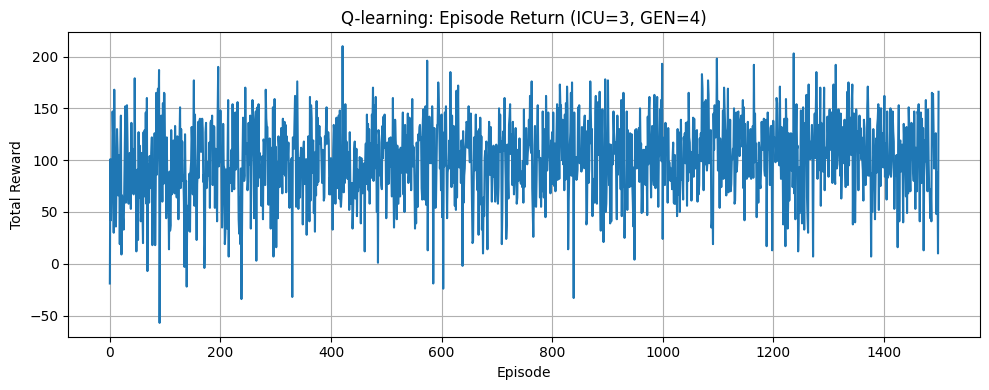

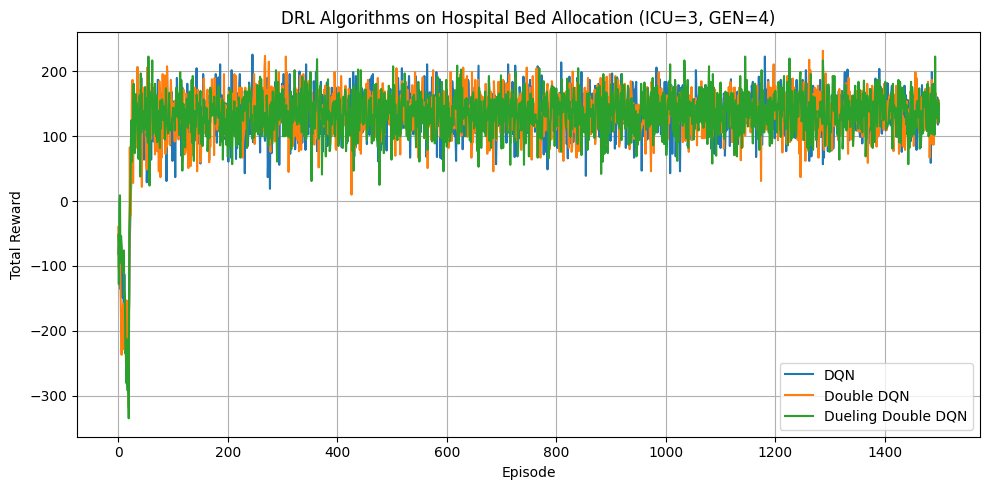

In [ ]:
# 5. RUN EXPERIMENTS

if __name__ == "__main__":
    # Q-learning
    Q, rewards_q = run_q_learning(episodes=1500)

    plt.figure(figsize=(10, 4))
    plt.plot(rewards_q)
    plt.title("Q-learning: Episode Return (ICU=3, GEN=4)")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Standard DQN
    rewards_dqn = train_dqn(
        episodes=1500,
        double_dqn=False,
        dueling=False
    )

    # Double DQN
    rewards_double = train_dqn(
        episodes=1500,
        double_dqn=True,
        dueling=False
    )

    # Dueling Double DQN
    rewards_dueling = train_dqn(
        episodes=1500,
        double_dqn=True,
        dueling=True
    )

    # Plot DRL results
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_dqn, label="DQN")
    plt.plot(rewards_double, label="Double DQN")
    plt.plot(rewards_dueling, label="Dueling Double DQN")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("DRL Algorithms on Hospital Bed Allocation (ICU=3, GEN=4)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
